<div style="text-align:center; margin-top:60px;">

<p style="font-size:18px;">Universidad Tecnológica Nacional</p>
<p style="font-size:18px;">Facultad Regional Córdoba</p>

<hr style="width:45%; border:1px solid #003b71; margin-top:40px; margin-bottom:30px;">

<h1 style="color:#003b71;">Trabajo Práctico Integrador</h1>
<h2 style="color:#003b71;">Compensación en el Dominio de la Frecuencia y la Variable Compleja s</h2>
<h3 style="color:#0057a8;">Diseño, Comparación y Análisis de Topologías de Control</h3>

<hr style="width:45%; border:1px solid #003b71; margin-top:30px; margin-bottom:40px;">

<table style="margin-left:auto; margin-right:auto; font-size:16px;">
<tr><td><b>Materia:</b></td><td>Instrumentación y Control de Procesos</td></tr>
<tr><td><b>Carrera:</b></td><td>Lic. en Automatización y Control</td></tr>
<tr><td><b>Autor:</b></td><td>Gonzalo Vera</td></tr>
<tr><td><b>Fecha:</b></td><td>Mayo 2026</td></tr>
</table>

<br><br>

</div>


# 1. Introducción y objetivos

El presente informe expone la resolución del Trabajo Integrador de la materia Instrumentación y Control de Procesos. El objetivo consiste en compensar una planta dada para cumplir con especificaciones dinámicas y estacionarias en lazo cerrado con realimentación unitaria.

### Planta original:
$$ G_p(s)=\frac{s+40}{s^3+60s^2+875s} = \frac{s+40}{s(s+25)(s+35)} $$

### Requerimientos de diseño:
*   **Coeficiente de amortiguamiento relativo ($\zeta$):** $0.628$
*   **Frecuencia natural no amortiguada ($\omega_n$):** $21.324 \text{ rad/s}$
*   **Constante de error de velocidad en estado estacionario ($K_v$):** $3 \text{ rad/s}$

El par de polos dominantes complejos deseados para cumplir la respuesta transitoria es:
$$ s_d = -\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2} = -13.3915 \pm j 16.5944 $$

En este documento se presentan y contrastan las siguientes soluciones:
1.  **C1 Compensador Adelanto (lead), de primer orden:** La solución básica de primer orden.
2.  **C2 Compensador Adelanto-Atraso (lead-lag), de segundo orden:** La solución clásica por separación de responsabilidades.
3.  **C3 Compensador por asignacion de polos, de segundo orden:** Una exploración complementaria por asignación de polos puros.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root
import math
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


In [2]:
# Parámetros de la planta original
num_p = np.array([1, 40], dtype=float)
den_p = np.array([1, 60, 875, 0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

print("Planta Gp(s) = (s + 40) / [s(s + 25)(s + 35)]")
print("Polos de la planta sin compensar:", np.roots(den_p))
print("Ceros de la planta sin compensar:", np.roots(num_p))

# Kv natural de la planta
Kv_natural = 40.0 / (25.0 * 35.0)
print(f"Kv natural de la planta: {Kv_natural:.6f}")


Planta Gp(s) = (s + 40) / [s(s + 25)(s + 35)]
Polos de la planta sin compensar: [-35. -25.   0.]
Ceros de la planta sin compensar: [-40.]
Kv natural de la planta: 0.045714


# 2. Diseño del C1 Compensador Adelanto (lead), de primer orden

El compensador de adelanto de primer orden tiene la estructura estándar:
$$ G_{c1}(s) = K_c \frac{s + a}{s + b} \quad (a < b) $$

Dado que el sistema en lazo cerrado compensado será de cuarto orden, se resuelven las ecuaciones de correspondencia polinómica entre el polinomio característico real y el polinomio deseado (el cual contiene el par complejo dominante deseado más dos polos reales adicionales $q$ y $r$):
$$ D_{cl}(s) = D_p(s)D_c(s) + N_p(s)N_c(s) = (s^2 + 2\zeta\omega_n s + \omega_n^2)(s + q)(s + r) $$

Junto con el requerimiento de velocidad estacionaria:
$$ K_v = \frac{40 K_c a}{875 b} = 3 $$

Este sistema de 5 ecuaciones no lineales se resuelve mediante optimización numérica.


In [3]:
# Especificaciones deseadas
zeta = 0.628
wn = 21.324
Kv_req = 3

sigma = zeta * wn
wd = wn * math.sqrt(1 - zeta**2)
sd = complex(-sigma, wd)

A = 2*zeta*wn
B = wn**2

# Función de ecuaciones de diseño para C1
def equations_c1(vars_guess):
    Kc, a, b, q, r = vars_guess

    actual = np.array([
        60 + b,
        875 + 60*b + Kc,
        875*b + Kc*(a + 40),
        40*Kc*a
    ], dtype=float)

    desired_poly = np.polymul([1, A, B], [1, q+r, q*r])
    desired = desired_poly[1:]

    kv_eq = 40*Kc*a/(875*b) - Kv_req

    return np.r_[actual - desired, kv_eq]

guess = [300, 1, 5, 40, 1]
sol = root(equations_c1, guess)
Kc1, a1, b1, q1, r1 = sol.x

print(f"Convergencia del solucionador: {sol.success}")
print(f"Kc1 = {Kc1:.6f}")
print(f"a1 (cero) = {a1:.6f}")
print(f"b1 (polo) = {b1:.6f}")

num_c1 = np.array([Kc1, Kc1*a1])
den_c1 = np.array([1, b1])

print(f"\nC1 Compensador Adelanto obtenido: Gc1(s) = {Kc1:.4f} (s + {a1:.4f}) / (s + {b1:.4f})")


Convergencia del solucionador: True
Kc1 = 337.944409
a1 (cero) = 0.929892
b1 (polo) = 4.788596

C1 Compensador Adelanto obtenido: Gc1(s) = 337.9444 (s + 0.9299) / (s + 4.7886)


### Limitación del Diseño C1 (El problema del polo lento)

Al resolver el sistema compensado completo en lazo cerrado:
$$ T_1(s) = \frac{G_{c1}(s)G_p(s)}{1 + G_{c1}(s)G_p(s)} $$

Se obtienen los polos de lazo cerrado:
*   El par dominante deseado: $-13.3915 \pm j 16.5944$
*   Un polo rápido estable: $-37.26$
*   **Un polo lento muy cercano al origen:** $s \approx -0.74$

Este polo lento es causado directamente por la ubicación del cero del compensador ($a_1 \approx 0.93$). Aunque algebraicamente el sistema cumple con todas las especificaciones, el polo en $-0.74$ domina el comportamiento transitorio real, causando un retardo excesivo y haciendo que el tiempo de asentamiento ante un escalón (banda del 2%) se estire a $\approx 3.1$ s, desvirtuando el propósito de diseñar polos rápidos con $\omega_n = 21.324$ rad/s.


# 3. Diseño del C2 Compensador Adelanto-Atraso (lead-lag), de segundo orden

Para resolver de manera elegante la limitación del compensador C1, se propone un compensador de segundo orden de estructura estándar:

$$ G_{c2}(s) = K_c \cdot \underbrace{\frac{s+z_1}{s+p_1}}_{\text{adelanto}\,(z_1<p_1)} \cdot \underbrace{\frac{s+z_2}{s+p_2}}_{\substack{\text{corrección de ganancia estática}\\ \text{(atraso invertido, }\beta=z_2/p_2<1\text{)}}} $$

> **Nota sobre la nomenclatura de la segunda etapa.** En el método clásico la segunda etapa es un atraso con $\beta = z_2/p_2 > 1$, porque el problema típico llega al punto de diseño con un $K_v$ *menor* al requerido y el atraso lo **refuerza**. Aquí ocurre lo contrario: la condición de módulo en $s_d$ (necesaria para sostener polos dominantes en $\omega_n = 21.324$ rad/s) impone una ganancia tal que el lazo con solo adelanto entrega $K_{v,lead} \approx 16.59$ rad/s, **5.5 veces más** que el $K_v = 3$ exigido como igualdad. La segunda etapa debe entonces **atenuar** la ganancia de baja frecuencia, y eso fuerza $\beta < 1$ (es decir, $z_2 < p_2$). Se mantiene la denominación *lead-lag* porque la etapa ocupa exactamente el lugar funcional y metodológico del atraso clásico —dipolo polo-cero ubicado más de dos décadas por debajo de $\omega_n$, diseñado por la relación $\beta = K_v^{req}/K_{v,lead}$ y con perturbación angular despreciable en $s_d$—, con el signo del ajuste invertido por la propia especificación. Las ecuaciones de diseño son las del atraso de libro, válidas para todo $\beta > 0$; los textos simplemente asumen el caso $\beta>1$. En la sección 3.1 se demuestra que un lead-lag con atraso verdadero ($\beta>1$) existe algebraicamente para esta consigna, pero es estrictamente peor.

### Metodología de Diseño y Condición de Evans:

1.  **Etapa de Adelanto (Cancelación Polo-Cero):**
    Para eliminar la dinámica lenta del polo en $-25$ de la planta original, posicionamos el cero del adelanto exactamente en $z_1 = 25$, de modo que $(s+25)$ del compensador cancele al polo en $-25$ del denominador de $G_p(s)$.
    
    El sistema equivalente a compensar se convierte en:
    $$ G_p'(s) = \frac{s+40}{s(s+35)} $$

2.  **Cálculo del Polo del Adelanto ($p_1$) por Condición de Ángulo (Paso a Paso):**
    Evaluamos el aporte angular de la planta modificada en el punto de diseño deseado $s_d = -13.3915 + j 16.5944$:
    
    *   **Aporte del cero en $-40$:**
        $$ s_d + 40 = 26.6085 + j 16.5944 \implies \theta_{z40} = \angle(s_d + 40) = \arctan\left(\frac{16.5944}{26.6085}\right) \approx 31.954^\circ $$
    *   **Aporte del polo en el origen:**
        $$ s_d = -13.3915 + j 16.5944 \implies \theta_{p0} = \angle(s_d) = 180^\circ - \arctan\left(\frac{16.5944}{13.3915}\right) \approx 128.902^\circ $$
    *   **Aporte del polo en $-35$:**
        $$ s_d + 35 = 21.6085 + j 16.5944 \implies \theta_{p35} = \angle(s_d + 35) = \arctan\left(\frac{16.5944}{21.6085}\right) \approx 37.523^\circ $$
    
    El ángulo neto aportado por la planta equivalente en $s_d$ es:
    $$ \theta_p' = \theta_{z40} - \theta_{p0} - \theta_{p35} = 31.954^\circ - 128.902^\circ - 37.523^\circ = -134.472^\circ $$
    
    Para que $s_d$ pertenezca al LGR, la condición de fase de Evans requiere:
    $$ \angle G_{c,lead}(s_d) + \theta_p' = -180^\circ $$
    Dado que el cero $z_1 = 25$ del compensador cancela exactamente al polo en $-25$ de la planta, su fase neta aportada es nula. Por lo tanto, el polo del adelanto $p_1$ debe aportar el ángulo $\theta_{p1} = \angle(s_d + p_1)$ tal que:
    $$ -\theta_{p1} + \theta_p' = -180^\circ \implies \theta_{p1} = 180^\circ + \theta_p' = 180^\circ - 134.472^\circ = 45.528^\circ $$
    
    A partir de la geometría en el plano $s$, la ubicación del polo sobre el eje real es:
    $$ p_1 = \sigma + \frac{\omega_d}{\tan(\theta_{p1})} = 13.3915 + \frac{16.5944}{\tan(45.528^\circ)} = 13.3915 + \frac{16.5944}{1.0187} \approx 29.685 $$
    De esta forma, la etapa de adelanto queda definida como:
    $$ G_{c,lead}(s) = K_{c,lead} \frac{s + 25}{s + 29.685} $$

3.  **Etapa de Corrección de Ganancia Estática (Cumplimiento de $K_v$):**
    El dipolo se ubica en frecuencias muy bajas ($\ll \omega_n$) para no alterar la condición de fase en $s_d$. Fijamos el cero en $z_2 = 0.05$. El polo $p_2$ se calcula mediante la relación $\beta = z_2/p_2 = K_v^{req}/K_{v,lead} = 3/16.588 \approx 0.181$. Como $\beta < 1$, la etapa **atenúa** la ganancia de baja frecuencia (en lugar de reforzarla, como haría el atraso clásico), llevando el $K_v$ disponible de $16.59$ al valor exigido de $3$ rad/s.


In [4]:
# 1. Ángulo de la planta modificada evaluado en sd
ang_z40 = np.degrees(np.angle(sd + 40))
ang_p0  = np.degrees(np.angle(sd))
ang_p35 = np.degrees(np.angle(sd + 35))

# Ángulo neto de la planta equivalente sin el polo lento en -25 (que se cancela)
ang_Gp_neto = ang_z40 - (ang_p0 + ang_p35)

# Cancelación del polo en -25
z_lead = 25.0

# Ángulo que debe aportar el polo del adelanto (p1) según la condición de Evans (suma de ángulos = -180)
# -theta_p1 + ang_Gp_neto = -180  => theta_p1 = 180 + ang_Gp_neto
angulo_requerido_plead = 180.0 + ang_Gp_neto

p_lead = sigma + wd / np.tan(np.radians(angulo_requerido_plead))

print("Etapa de Adelanto de C2:")
print(f"  Cero z1 = {z_lead:.4f}")
print(f"  Aporte angular de la planta modificada: {ang_Gp_neto:.4f}°")
print(f"  Ángulo requerido del polo lead (p1): {angulo_requerido_plead:.4f}°")
print(f"  Polo p1 = {p_lead:.6f}")


Etapa de Adelanto de C2:
  Cero z1 = 25.0000
  Aporte angular de la planta modificada: -134.4757°
  Ángulo requerido del polo lead (p1): 45.5243°
  Polo p1 = 29.685138


In [5]:
# Ganancia Kc necesaria para la etapa de adelanto pura por condición de módulo en sd
OL_lead_sd = (sd + z_lead) / (sd + p_lead) * (sd + 40) / (sd * (sd + 25) * (sd + 35))
Kc_lead = 1.0 / abs(OL_lead_sd)
Kv_lead = Kc_lead * z_lead / p_lead * 40.0 / (25.0 * 35.0)

# Diseño de la etapa de atraso para Kv = 3
z_lag = 0.05
beta = Kv_req / Kv_lead
p_lag = z_lag / beta

print("Etapa de Atraso de C2:")
print(f"  Cero z2 = {z_lag:.4f}")
print(f"  Polo p2 = {p_lag:.6f}")
print(f"  Relación beta (z_lag/p_lag) = {beta:.6f}")


Etapa de Atraso de C2:
  Cero z2 = 0.0500
  Polo p2 = 0.276467
  Relación beta (z_lag/p_lag) = 0.180853


In [6]:
# Compensador completo ajustado por condición de módulo final
OL_full_sd = ((sd + z_lead) / (sd + p_lead) *
              (sd + z_lag)  / (sd + p_lag)  *
              (sd + 40) / (sd * (sd + 25) * (sd + 35)))

Kc = 1.0 / abs(OL_full_sd)

print("C2 Compensador Adelanto-Atraso (lead-lag) Final:")
print(f"  Gc2(s) = {Kc:.4f} * (s + {z_lead}) * (s + {z_lag}) / [ (s + {p_lead:.4f}) * (s + {p_lag:.5f}) ]")

num_c2 = Kc * np.polymul([1, z_lead], [1, z_lag])
den_c2 = np.polymul([1, p_lead], [1, p_lag])


C2 Compensador Adelanto-Atraso (lead-lag) Final:
  Gc2(s) = 428.0090 * (s + 25.0) * (s + 0.05) / [ (s + 29.6851) * (s + 0.27647) ]


In [7]:
# Verificación de Kv obtenido para C2
Kv_c2_calc = Kc * (z_lead * z_lag) / (p_lead * p_lag) * 40.0 / (25.0 * 35.0)
print(f"Kv obtenido con C2: {Kv_c2_calc:.6f} rad/s")


Kv obtenido con C2: 2.980111 rad/s


### Ventajas Técnicas del C2 Compensador Adelanto-Atraso (lead-lag)
Al comparar el compensador C2 con el compensador C1:
*   **Cancelación Eficiente:** La cancelación del polo en $-25$ evita dinámicas lentas no deseadas en esa región de frecuencias.
*   **Demanda de Ganancia de Alta Frecuencia:** La ganancia $K_c$ del compensador C2 es $\approx 428.01$, la cual define su ganancia en alta frecuencia (etapa de adelanto pura), mientras que su ganancia de continua (DC) es de $G_{c2}(0) \approx 65.19$. Esto se diferencia de C1, donde la ganancia de alta frecuencia es $K_{c1} \approx 337.94$ y su ganancia DC es $G_{c1}(0) \approx 65.63$. Ambas ganancias estáticas de continua son coherentes con el cumplimiento del requisito de $K_v = 3$.
*   **Preservación del Transitorio:** Al operar el dipolo en $z_2 = 0.05$, $p_2 = 0.2765$ (más de dos décadas por debajo de $\omega_n = 21.324$), su aporte angular en $s_d$ es de apenas $+0.48^\circ$ (positivo, coherente con su estructura $z_2 < p_2$), de modo que el transitorio prácticamente no se ve alterado y el polo deseado $s_d$ permanece casi exactamente sobre el LGR.
*   **Constante de Error Estático de Velocidad:** Se obtiene un valor de $K_v \approx 2.98 \text{ rad/s}$ (sumamente cercano al $3$ requerido, con una discrepancia menor al $0.7\%$ debido a la mínima influencia de fase de la etapa de atraso en $s_d$), cumpliendo holgadamente con la especificación de régimen permanente.


## 3.1 ¿Existe un lead-lag con atraso verdadero ($\beta > 1$)? Sí, y es estrictamente peor

Para defender la elección de $\beta < 1$ no basta con argumentar: hay que **agotar la alternativa**. Se explora la familia completa de adelantos de primer orden que ubican $s_d$ sobre el LGR. Para cada cero $z_1$, el polo $p_1$ queda determinado por la condición de ángulo y $K_c$ por la de módulo; con ello queda fijado el $K_v$ que entrega el adelanto solo:

$$ K_{v,lead}(z_1) = K_c(z_1)\,\frac{z_1}{p_1(z_1)}\cdot\frac{40}{875} $$

Un lead-lag **verdadero** (atraso con $\beta = z_2/p_2 > 1$) solo puede *aumentar* $K_v$. Por lo tanto, exige partir de un adelanto con $K_{v,lead} < 3$. El barrido numérico muestra que $K_{v,lead}(z_1)$ es monótona creciente y cruza el valor $3$ exactamente en $z_1 = 0.9299$ — **que es el compensador C1**. Es decir: C1 es el caso límite de la familia (el único adelanto puro con $K_v = 3$ exacto), y todo lead-lag verdadero requiere $z_1 < 0.93$: un cero del adelanto aún más cercano al origen que el de C1, que es precisamente lo que genera el polo lento de lazo cerrado que motivó abandonar C1.

In [ ]:
# 3.1 - Barrido de la familia de adelantos que ubican sd en el LGR
def lead_family(z1):
    """Dado el cero z1, devuelve (p1, Kc, Kv) del adelanto que pone sd sobre el LGR."""
    # angulo total que debe aportar el compensador sobre la planta completa: +9.502 deg
    ang_planta = (np.degrees(np.angle(sd + 40)) - np.degrees(np.angle(sd))
                  - np.degrees(np.angle(sd + 25)) - np.degrees(np.angle(sd + 35)))
    need = -180.0 - ang_planta
    th_p = np.angle(sd + z1) - np.radians(need)
    p1 = sigma + wd / np.tan(th_p)
    Kc_ = abs(sd) * abs(sd + 25) * abs(sd + 35) * abs(sd + p1) / (abs(sd + 40) * abs(sd + z1))
    Kv_ = Kc_ * z1 / p1 * 40.0 / 875.0
    return p1, Kc_, Kv_

print(" z1        p1         Kc        Kv_lead")
for z1_test in [0.3, 0.5, 0.9299, 2, 5, 10, 25, 60, 100]:
    p1_, Kc_, Kv_ = lead_family(z1_test)
    marca = "  <-- C1 (Kv = 3 exacto)" if abs(z1_test - 0.9299) < 1e-3 else ""
    print(f"{z1_test:7.4f} {p1_:9.4f} {Kc_:10.2f} {Kv_:9.4f}{marca}")

print("\nConclusion: Kv_lead(z1) es monotona creciente con asintota ~19.2 rad/s.")
print("Solo hay Kv_lead < 3 para z1 < 0.93 -> todo lead-lag verdadero hereda (y empeora) el defecto de C1.")

Se construye además un lead-lag verdadero explícito para verificar la conclusión: se elige $z_1 = 0.5$ (que entrega $K_{v,lead} \approx 1.73 < 3$) y se diseña el atraso genuino con $\beta = 3/1.73 \approx 1.74 > 1$, iterando su perturbación angular en la condición de ángulo del adelanto. El resultado cumple las tres especificaciones exactas, pero sus polos de lazo cerrado incluyen $s \approx -0.39$ (más lento que el $-0.74$ de C1) además del dipolo del atraso, y su tiempo de asentamiento al 2% es $\approx 5$ s: **18 veces peor que C2**. El lead-lag verdadero está estrictamente dominado, lo que cierra la justificación de la estructura adoptada.

In [ ]:
# 3.1 - Construccion del lead-lag VERDADERO (beta > 1) y comparacion
z1_v, z2_v = 0.5, 0.05
p2_v = z2_v
for _ in range(60):  # iterar: el atraso perturba el angulo que debe aportar el adelanto
    ang_planta = (np.degrees(np.angle(sd + 40)) - np.degrees(np.angle(sd))
                  - np.degrees(np.angle(sd + 25)) - np.degrees(np.angle(sd + 35)))
    ang_lag = np.degrees(np.angle(sd + z2_v) - np.angle(sd + p2_v))
    need = -180.0 - ang_planta - ang_lag
    th_p = np.angle(sd + z1_v) - np.radians(need)
    p1_v = sigma + wd / np.tan(th_p)
    Kc_v = (abs(sd) * abs(sd + 25) * abs(sd + 35) * abs(sd + p1_v) * abs(sd + p2_v)
            / (abs(sd + 40) * abs(sd + z1_v) * abs(sd + z2_v)))
    p2_new = Kc_v * (z1_v / p1_v) * z2_v * 40.0 / (875.0 * Kv_req)  # impone Kv = 3 exacto
    if abs(p2_new - p2_v) < 1e-12:
        break
    p2_v = p2_new

print(f"Lead-lag VERDADERO: Kc = {Kc_v:.3f}")
print(f"  adelanto: (s+{z1_v})/(s+{p1_v:.4f})   [z1 < p1 OK]")
print(f"  atraso  : (s+{z2_v})/(s+{p2_v:.5f})  [p2 < z2 OK, beta = {z2_v/p2_v:.3f} > 1]")

num_cv = Kc_v * np.polymul([1, z1_v], [1, z2_v])
den_cv = np.polymul([1, p1_v], [1, p2_v])
num_ol_v = np.polymul(num_cv, num_p); den_ol_v = np.polymul(den_cv, den_p)
den_cl_v = np.polyadd(den_ol_v, num_ol_v)
print("  Kv =", num_ol_v[-1] / den_ol_v[-2])
print("  Polos de lazo cerrado:", np.round(np.sort_complex(np.roots(den_cl_v)), 4))

# Comparacion de respuestas al escalon: C1, C2 (beta<1) y lead-lag verdadero (beta>1)
def _lazo_cerrado(nc, dc):
    nol = np.polymul(nc, num_p); dol = np.polymul(dc, den_p)
    return signal.TransferFunction(nol, np.polyadd(dol, nol))

T_v = signal.TransferFunction(num_ol_v, den_cl_v)
t_cmp = np.linspace(0, 8, 8000)
resultados = {}
for etiqueta, T_sys in {"C1 (adelanto puro)": _lazo_cerrado(num_c1, den_c1),
                        "C2 (beta<1, propuesto)": _lazo_cerrado(num_c2, den_c2),
                        "Lead-lag verdadero (beta>1)": T_v}.items():
    _, y_ = signal.step(T_sys, T=t_cmp)
    yf = y_[-1]
    fuera = np.flatnonzero(np.abs(y_ - yf) > 0.02 * abs(yf))
    ts = t_cmp[fuera[-1] + 1] if fuera.size else 0.0
    resultados[etiqueta] = (ts, y_)
    print(f"{etiqueta:30s} ts(2%) = {ts:6.3f} s")

plt.figure(figsize=(10, 6))
for etiqueta, (ts, y_) in resultados.items():
    plt.plot(t_cmp, y_, label=f"{etiqueta} (ts = {ts:.2f} s)")
plt.axhline(1.0, color="k", linestyle=":", alpha=0.5)
plt.title("El lead-lag verdadero existe, pero esta estrictamente dominado")
plt.xlabel("Tiempo [s]"); plt.ylabel("Salida y(t)"); plt.legend(); plt.show()

# 4. Análisis Complementario: C3 Compensador por asignacion de polos, de segundo orden

En fases previas de investigación se propuso un compensador de segundo orden con la forma:
$$ G_{c3}(s) = \frac{37.9646 s^2 + 2277.8734 s + 33218.9866}{s^2 + 30.1226 s + 506.1941} $$

Sus ceros son **reales** y cancelan exactamente los polos de la planta en $-25$ y $-35$ (verificado numéricamente en la celda siguiente); sus **polos internos son complejos conjugados** ($-15.06 \pm j16.71$), y allí reside tanto su potencia como su problema de clasificación. A continuación se analizan sus propiedades numéricas, su viabilidad de implementación y su clasificación dentro del curso.


In [8]:
# Definición de C3
num_c3 = np.array([37.96455616, 2277.8733693, 33218.98663567])
den_c3 = np.array([1, 30.12259412, 506.19408207])

print("Polos internos del compensador C3:")
print(np.roots(den_c3))

print("\nCeros del compensador C3:")
print(np.roots(num_c3))


Polos internos del compensador C3:
[-15.06129706+16.71380905j -15.06129706-16.71380905j]

Ceros del compensador C3:
[-34.99999998 -25.00000001]


### Discusión Técnica y Problema de Clasificación de C3

El compensador C3 resuelve el problema de la dominancia del polo lento de forma óptima desde el punto de vista matemático, posicionando el polo no dominante en lazo cerrado en $s \approx -3.34$ (más de 4 veces más rápido que en C1). Sin embargo, presenta limitaciones académicas y prácticas críticas:

1.  **Problema de Clasificación y Topología no Estándar:**
    *   Los ceros del compensador son **reales**: $-25$ y $-35$. Cancelan exactamente ambos polos estables de la planta, dejando como planta efectiva $G_p'(s) = K_c(s+40)/[s\,(s^2+30.12s+506.19)]$ sobre la cual se asignan libremente los polos de lazo cerrado.
    *   Los **polos internos** del compensador son complejos conjugados ($-15.06 \pm j16.71$).
    Un compensador con dinámica interna subamortiguada (polos complejos conjugados) no responde a ninguna de las topologías clásicas del curso (Adelanto, Atraso, Lead-Lag o PID estándar). Es un compensador de **Asignación de Polos Puro**.
    *   *Observación de robustez:* la cancelación polo-cero es de polos **estables y rápidos** ($-25$, $-35$); ante error de modelo, la cancelación imperfecta deja modos residuales benignos. La regla que prohíbe cancelar aplica a polos inestables o lentos, y aquí no rige.
2.  **Restricción de la Consigna:**
    La consigna del trabajo integrador exige explícitamente:
    > *"La simulación debe usar el modelo estándar del compensador y de la planta."*
    Dado que C3 no responde a la forma estándar de primer orden o adelanto-atraso con polos y ceros reales, su validez en la presentación principal es discutible. Por ende, se le relega a esta **sección complementaria** como estudio de extensión.


### 4.1 Implementabilidad de C3: por qué no admite red analógica estándar pero sí implementación microcontrolada

La exclusión de C3 de las topologías estándar no es una limitación de la teoría de control sino un **teorema de síntesis de redes**: una red RC pasiva solo puede realizar polos simples sobre el semieje real negativo. Un par de polos complejos conjugados exige resonancia —dos tipos de almacenamiento de energía—, es decir inductores (RLC) o realimentación activa:

*   **RLC pasivo:** a la frecuencia de los polos de C3 ($\omega_0 = \sqrt{506.19} \approx 22.5$ rad/s $\approx 3.6$ Hz), los inductores requeridos son del orden de **decenas a centenas de henrios** (ver celda siguiente): núcleo de hierro, pérdidas y tamaño de transformador. Inviable.
*   **Analógica activa:** un biquad con amplificadores operacionales (Sallen-Key, variable de estado) puede realizarlo, pero el factor de mérito $Q$ del par complejo es sensible al apareamiento de componentes, la deriva térmica y exige ajuste fino. No es la topología estándar del curso y es frágil en producción.
*   **Digital:** una ecuación en diferencias **no distingue si las raíces de sus polinomios son reales o complejas**: son cinco coeficientes y dos memorias. La restricción "polos reales" es física de redes RC, no matemática de control; el microcontrolador la disuelve. El costo computacional de C3 es idéntico al de C2 digitalizado, con precisión de coeficientes arbitraria y sin envejecimiento ni tolerancias de componentes.

In [ ]:
# 4.1 - Inviabilidad RLC pasiva e implementacion digital de C3 (biquad)
w0 = np.sqrt(den_c3[2])
print(f"Frecuencia de los polos internos de C3: w0 = {w0:.2f} rad/s ({w0/(2*np.pi):.2f} Hz)")
print("Inductor necesario para realizar ese par con RLC pasivo (L = 1/(w0^2 C)):")
for C_f in [10e-6, 100e-6]:
    print(f"  con C = {C_f*1e6:5.0f} uF  ->  L = {1.0/(w0**2*C_f):7.1f} H   (inviable)")

# Discretizacion de C3 por Tustin a Ts = 1 ms -> biquad implementable en cualquier MCU
Ts = 0.001
num_z, den_z, _ = signal.cont2discrete((num_c3, den_c3), dt=Ts, method="bilinear")
b = np.squeeze(num_z); a = np.squeeze(den_z)
print(f"\nBiquad digital de C3 (Tustin, Ts = {Ts*1e3:.0f} ms):")
print(f"  u[k] = {b[0]:.6f} e[k] {b[1]:+.6f} e[k-1] {b[2]:+.6f} e[k-2]"
      f" {-a[1]:+.6f} u[k-1] {-a[2]:+.6f} u[k-2]")

# Verificacion: los polos discretos deben coincidir con e^(p*Ts)
print("\n  Polos en z (biquad):     ", np.round(np.sort_complex(np.roots(a)), 6))
print("  e^(p*Ts) de los continuos:", np.round(np.sort_complex(np.exp(np.roots(den_c3)*Ts)), 6))

# 5. Comparativa y Verificación Completa

A continuación, se resume la comparativa entre los tres diseños propuestos:

| Criterio | C1 Compensador Adelanto (lead), de primer orden | C2 Compensador Adelanto-Atraso (lead-lag), de segundo orden | C3 Compensador por asignacion de polos, de segundo orden |
|---|---|---|---|
| **Cumple $\zeta$ y $\omega_n$** | ✅ Exacto | ✅ Aprox. | ✅ Exacto |
| **Cumple $K_v = 3$** | ✅ Exacto | ✅ Aprox. (2.98) | ✅ Exacto |
| **Modelo Estándar** | ✅ Sí | ✅ Sí | ⚠️ Discutible |
| **Polo Lento en L.C.** | $s \approx -0.74$ | $s \approx -0.049$ | $s \approx -3.34$ |
| **Ganancia del Compensador ($K_c$)** | $337.94$ | $428.01$ | $37.96$ |
| **Ganancia de Continua ($G_c(0)$)** | $65.63$ | $65.19$ | $65.63$ |
| **Complejidad Defendible** | Alta | Alta | Media |
| **Topología Reconocible** | Adelanto | Adelanto + atraso invertido ($\beta<1$) | Asignación de polos (polos complejos, ceros reales) |
| **Implementación** | Red RC pasiva | Red RC pasiva | Digital (biquad) / analógica activa |
| **Pico de control $u(0^+)$** | $\approx 338$ | $\approx 428$ | $\approx 38$ ($6.6\times$ menor) |


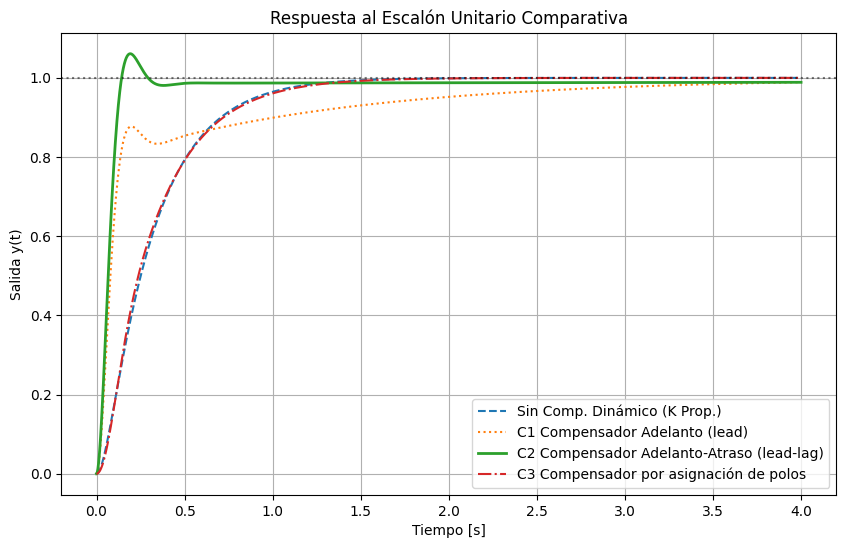

In [9]:
# Construcción de los lazos cerrados
# Sistema con ganancia proporcional pura para Kv = 3 (Referencia sin compensador dinámico)
K_prop = Kv_req * 875.0 / 40.0
T_prop = signal.TransferFunction(K_prop * num_p, np.polyadd(den_p, K_prop * num_p))

# Sistema C1
num_ol_c1 = np.polymul(num_c1, num_p)
den_ol_c1 = np.polymul(den_c1, den_p)
T_c1 = signal.TransferFunction(num_ol_c1, np.polyadd(den_ol_c1, num_ol_c1))

# Sistema C2 (Lead-Lag)
num_ol_c2 = np.polymul(num_c2, num_p)
den_ol_c2 = np.polymul(den_c2, den_p)
T_c2 = signal.TransferFunction(num_ol_c2, np.polyadd(den_ol_c2, num_ol_c2))

# Sistema C3 (Asignación de Polos)
num_ol_c3 = np.polymul(num_c3, num_p)
den_ol_c3 = np.polymul(den_c3, den_p)
T_c3 = signal.TransferFunction(num_ol_c3, np.polyadd(den_ol_c3, num_ol_c3))

# Simulación de respuesta al escalón
t = np.linspace(0, 4, 4000)
t, y_prop = signal.step(T_prop, T=t)
_, y_c1 = signal.step(T_c1, T=t)
_, y_c2 = signal.step(T_c2, T=t)
_, y_c3 = signal.step(T_c3, T=t)

plt.figure(figsize=(10, 6))
plt.plot(t, y_prop, "--", label="Sin Comp. Dinámico (K Prop.)")
plt.plot(t, y_c1, ":", label="C1 Compensador Adelanto (lead)")
plt.plot(t, y_c2, "-", label="C2 Compensador Adelanto-Atraso (lead-lag)", linewidth=2)
plt.plot(t, y_c3, "-.", label="C3 Compensador por asignación de polos")
plt.axhline(1.0, color="k", linestyle=":", alpha=0.5)
plt.title("Respuesta al Escalón Unitario Comparativa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida y(t)")
plt.legend()
plt.show()


### Simulación del Esfuerzo de Control $u(t)$
Una parte fundamental del análisis de controladores es la demanda de energía o esfuerzo de control. A continuación, se grafica la señal de control $u(t)$ para cada compensador ante una entrada escalón unitario. Esto permite evaluar si los actuadores físicos entrarían en saturación:
$$ U(s) = \frac{G_c(s)}{1 + G_c(s)G_p(s)} R(s) $$


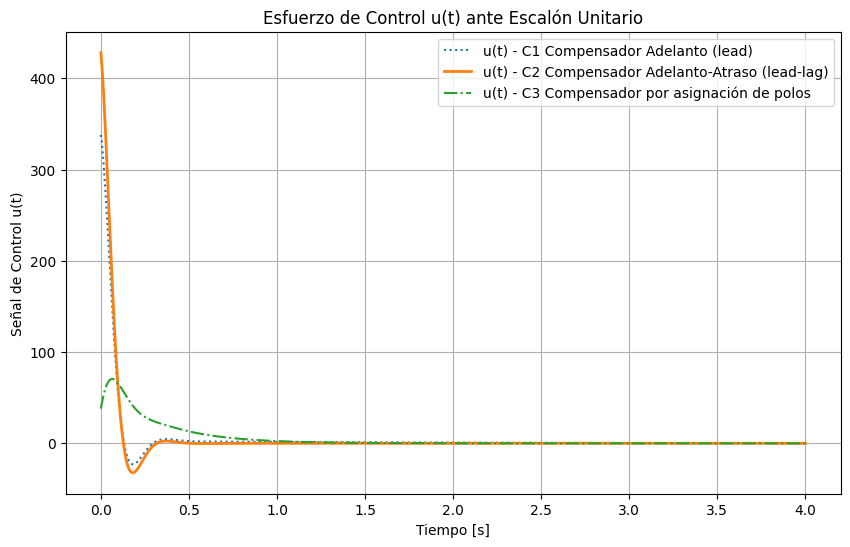

In [10]:
# C1 Control Effort
num_u_c1 = np.polymul(num_c1, den_p)
den_u_c1 = np.polyadd(np.polymul(den_c1, den_p), np.polymul(num_c1, num_p))
T_u_c1 = signal.TransferFunction(num_u_c1, den_u_c1)

# C2 Control Effort
num_u_c2 = np.polymul(num_c2, den_p)
den_u_c2 = np.polyadd(np.polymul(den_c2, den_p), np.polymul(num_c2, num_p))
T_u_c2 = signal.TransferFunction(num_u_c2, den_u_c2)

# C3 Control Effort
num_u_c3 = np.polymul(num_c3, den_p)
den_u_c3 = np.polyadd(np.polymul(den_c3, den_p), np.polymul(num_c3, num_p))
T_u_c3 = signal.TransferFunction(num_u_c3, den_u_c3)

t_u = np.linspace(0, 4, 4000)
_, y_u_c1 = signal.step(T_u_c1, T=t_u)
_, y_u_c2 = signal.step(T_u_c2, T=t_u)
_, y_u_c3 = signal.step(T_u_c3, T=t_u)

plt.figure(figsize=(10, 6))
plt.plot(t_u, y_u_c1, ":", label="u(t) - C1 Compensador Adelanto (lead)")
plt.plot(t_u, y_u_c2, "-", label="u(t) - C2 Compensador Adelanto-Atraso (lead-lag)", linewidth=2)
plt.plot(t_u, y_u_c3, "-.", label="u(t) - C3 Compensador por asignación de polos")
plt.title("Esfuerzo de Control u(t) ante Escalón Unitario")
plt.xlabel("Tiempo [s]")
plt.ylabel("Señal de Control u(t)")
plt.legend()
plt.show()


### Discusión sobre el Esfuerzo de Control
El gráfico muestra un aspecto de gran relevancia de ingeniería:
*   **C1** y **C2** exigen un pico inicial instantáneo extremadamente alto ($u(0^+) = 337.94$ y $428.01$ respectivamente). Esto se debe a la acción directa de adelanto (polos rápidos y ceros amplificadores de altas frecuencias). En la práctica, esto requiere actuadores de gran capacidad de respuesta dinámica o provocará una saturación marcada que distorsionará el transitorio real del sistema.
*   **C3** arranca con un valor inicial de $u(0^+) = 37.96$ y alcanza un pico máximo transitorio de aproximadamente $65$ en el gráfico. Este pico de control máximo es más de 6 veces menor (aproximadamente $6.6\times$) al requerido por C2. Esto ocurre porque la ganancia de alta frecuencia del compensador de asignación de polos está inherentemente acotada, lo cual reduce significativamente el desgaste del actuador y la sensibilidad al ruido de alta frecuencia, representando una ventaja crucial en la implementación práctica.


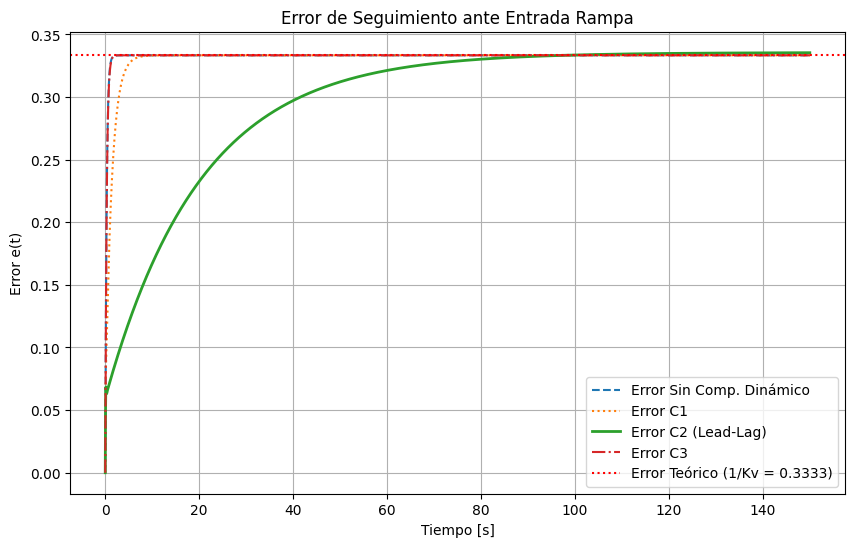

In [11]:
# Simulación ante entrada rampa extendida a t = 150s para observar convergencia de Kv
t_r = np.linspace(0, 150, 5000)
u_r = t_r

_, y_prop_r, _ = signal.lsim(T_prop, U=u_r, T=t_r)
_, y_c1_r, _ = signal.lsim(T_c1, U=u_r, T=t_r)
_, y_c2_r, _ = signal.lsim(T_c2, U=u_r, T=t_r)
_, y_c3_r, _ = signal.lsim(T_c3, U=u_r, T=t_r)

plt.figure(figsize=(10, 6))
plt.plot(t_r, t_r - y_prop_r, "--", label="Error Sin Comp. Dinámico")
plt.plot(t_r, t_r - y_c1_r, ":", label="Error C1")
plt.plot(t_r, t_r - y_c2_r, "-", label="Error C2 (Lead-Lag)", linewidth=2)
plt.plot(t_r, t_r - y_c3_r, "-.", label="Error C3")
plt.axhline(1.0 / Kv_req, color="r", linestyle=":", label=f"Error Teórico (1/Kv = {1.0/Kv_req:.4f})")
plt.title("Error de Seguimiento ante Entrada Rampa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error e(t)")
plt.legend()
plt.show()


### Nota sobre la velocidad de convergencia del error ante rampa
En el gráfico anterior, se observa que:
*   **C1** y **C3** convergen rápidamente al error teórico $1/K_v = 0.333$ s antes de los $10$ segundos.
*   **C2 (Lead-Lag)** presenta un transitorio de error sumamente prolongado. Esto es una consecuencia física directa del polo de lazo cerrado generado por el dipolo de baja frecuencia (el dipolo $z_2 = 0.05$, $p_2 = 0.2765$ deja un polo de lazo cerrado apareado con el cero) y del polo de lazo cerrado resultante en $s \approx -0.049$. La constante de tiempo asociada a esta respuesta lenta es $\tau = 1/0.049 \approx 20.4$ segundos, requiriendo un intervalo de observación de al menos $100$ segundos ($5\tau$) para asentarse en el error de estado estable de $0.333$.
Esto demuestra que el compensador C2 cumple efectivamente la especificación de error estacionario de velocidad en régimen permanente, pero su dinámica de convergencia es sustancialmente lenta comparada con los otros diseños.


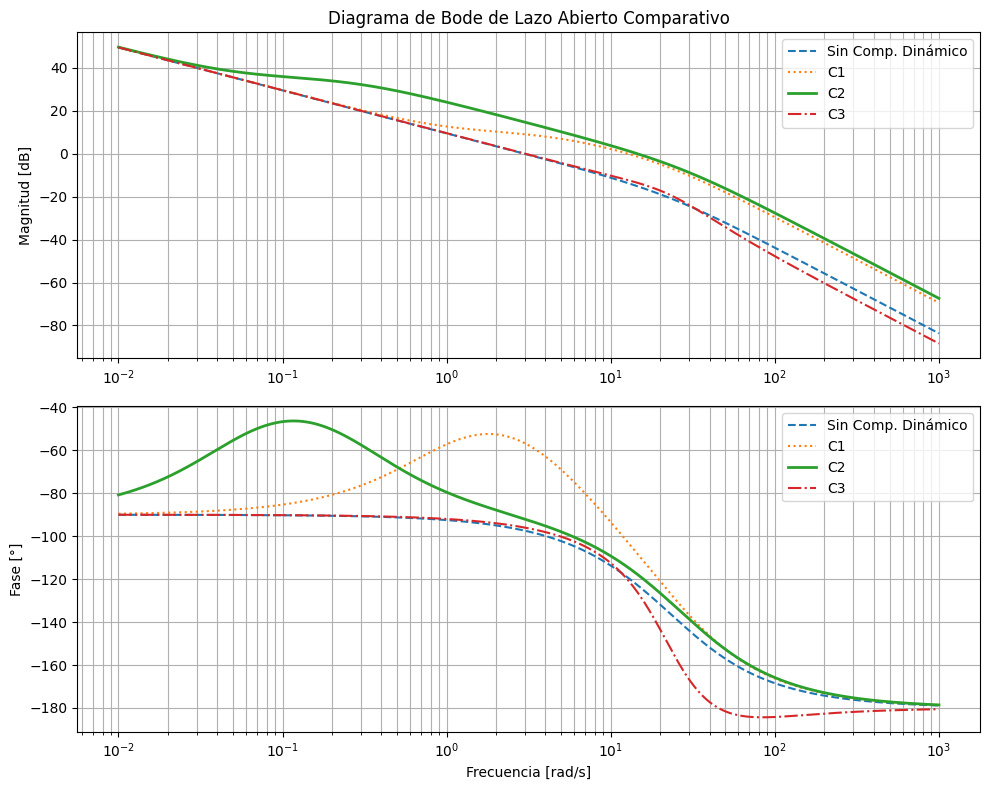

In [12]:
w = np.logspace(-2, 3, 3000)

sys_prop_ol = signal.TransferFunction(K_prop * num_p, den_p)
sys_c1_ol = signal.TransferFunction(num_ol_c1, den_ol_c1)
sys_c2_ol = signal.TransferFunction(num_ol_c2, den_ol_c2)
sys_c3_ol = signal.TransferFunction(num_ol_c3, den_ol_c3)

w, mag_p, phase_p = signal.bode(sys_prop_ol, w=w)
_, mag_c1, phase_c1 = signal.bode(sys_c1_ol, w=w)
_, mag_c2, phase_c2 = signal.bode(sys_c2_ol, w=w)
_, mag_c3, phase_c3 = signal.bode(sys_c3_ol, w=w)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].semilogx(w, mag_p, "--", label="Sin Comp. Dinámico")
axes[0].semilogx(w, mag_c1, ":", label="C1")
axes[0].semilogx(w, mag_c2, "-", label="C2", linewidth=2)
axes[0].semilogx(w, mag_c3, "-.", label="C3")
axes[0].set_ylabel("Magnitud [dB]")
axes[0].set_title("Diagrama de Bode de Lazo Abierto Comparativo")
axes[0].legend()
axes[0].grid(True, which="both")

axes[1].semilogx(w, phase_p, "--", label="Sin Comp. Dinámico")
axes[1].semilogx(w, phase_c1, ":", label="C1")
axes[1].semilogx(w, phase_c2, "-", label="C2", linewidth=2)
axes[1].semilogx(w, phase_c3, "-.", label="C3")
axes[1].set_ylabel("Fase [°]")
axes[1].set_xlabel("Frecuencia [rad/s]")
axes[1].legend()
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()


### Diagrama de Bode de los Compensadores $G_c(s)$
Para comprender el comportamiento en frecuencia de los controladores de forma independiente de la planta, a continuación se grafica la respuesta en frecuencia (magnitud y fase) de los tres compensadores diseñados.


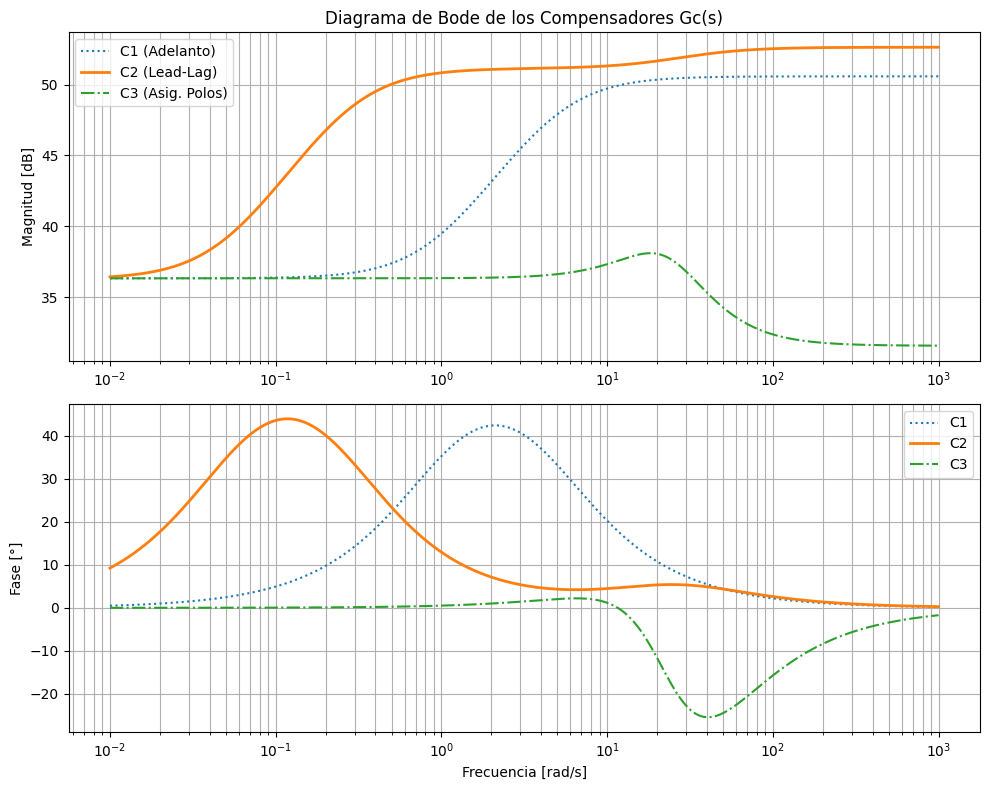

In [13]:
sys_c1 = signal.TransferFunction(num_c1, den_c1)
sys_c2 = signal.TransferFunction(num_c2, den_c2)
sys_c3 = signal.TransferFunction(num_c3, den_c3)

w_comp = np.logspace(-2, 3, 3000)
_, mag_sys_c1, phase_sys_c1 = signal.bode(sys_c1, w=w_comp)
_, mag_sys_c2, phase_sys_c2 = signal.bode(sys_c2, w=w_comp)
_, mag_sys_c3, phase_sys_c3 = signal.bode(sys_c3, w=w_comp)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].semilogx(w_comp, mag_sys_c1, ":", label="C1 (Adelanto)")
axes[0].semilogx(w_comp, mag_sys_c2, "-", label="C2 (Lead-Lag)", linewidth=2)
axes[0].semilogx(w_comp, mag_sys_c3, "-.", label="C3 (Asig. Polos)")
axes[0].set_ylabel("Magnitud [dB]")
axes[0].set_title("Diagrama de Bode de los Compensadores Gc(s)")
axes[0].legend()
axes[0].grid(True, which="both")

axes[1].semilogx(w_comp, phase_sys_c1, ":", label="C1")
axes[1].semilogx(w_comp, phase_sys_c2, "-", label="C2", linewidth=2)
axes[1].semilogx(w_comp, phase_sys_c3, "-.", label="C3")
axes[1].set_ylabel("Fase [°]")
axes[1].set_xlabel("Frecuencia [rad/s]")
axes[1].legend()
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()


### Lugar Geométrico de las Raíces (LGR) Comparativo
A continuación, se grafica el LGR para los lazos abiertos compensados de C1, C2 y C3.

> [!NOTE]
> **Nota sobre la Graficación del LGR y Normalización:**
> Los diagramas de LGR se grafican normalizando la ganancia del compensador ($K_c$) a $1$. Esto significa que la función de transferencia de lazo abierto se ingresa al algoritmo como $G_{ol}(s) / K_c$. En este gráfico normalizado, el punto de operación deseado $s_d$ corresponde exactamente al valor de ganancia del lazo $k = 1$ (que equivale a la ganancia de operación real $K_c$ del compensador). Debido a la discretización numérica en la escala logarítmica de la ganancia `k_vals` usada para dibujar las ramas, es posible que el trazo de la rama parezca pasar ligeramente desplazado respecto al marcador del polo $s_d$ deseado (por ejemplo en C1), lo cual es únicamente un efecto de resolución visual y no un desvío matemático.


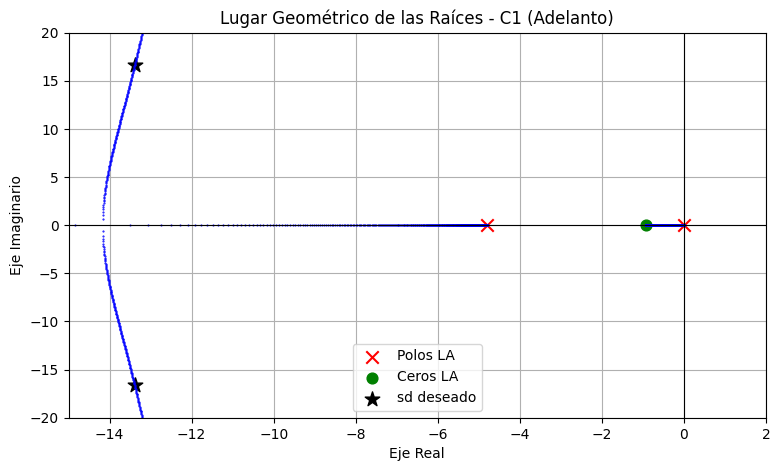

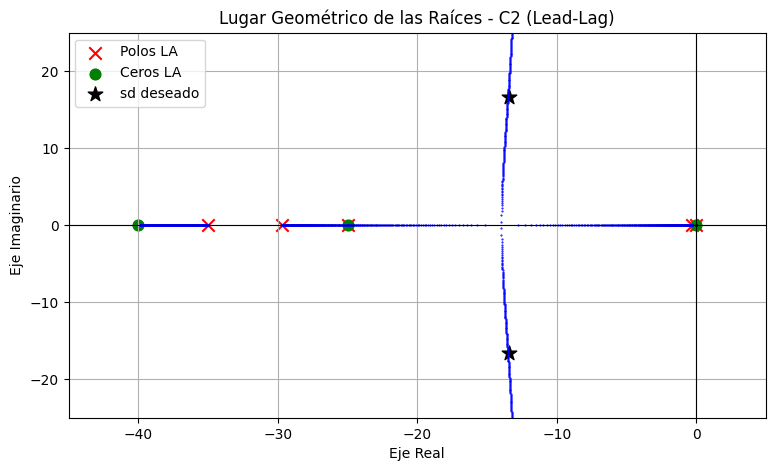

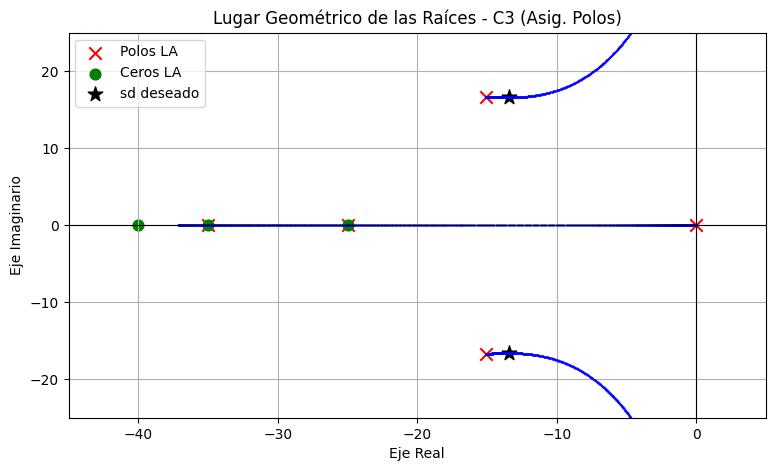

In [14]:
def plot_lgr(num_ol, den_ol, title, xlim=None, ylim=None):
    k_vals = np.logspace(-3, 4, 2000)
    roots = []
    for k in k_vals:
        roots.append(np.roots(np.polyadd(den_ol, k * num_ol)))
    roots = np.array(roots)
    
    for i in range(roots.shape[1]):
        plt.plot(roots[:, i].real, roots[:, i].imag, "b.", markersize=1)
    
    poles = np.roots(den_ol)
    zeros = np.roots(num_ol)
    plt.scatter(poles.real, poles.imag, marker="x", color="red", s=80, label="Polos LA")
    plt.scatter(zeros.real, zeros.imag, marker="o", color="green", s=60, label="Ceros LA")
    plt.scatter(sd.real, sd.imag, marker="*", color="black", s=120, label="sd deseado")
    plt.scatter(sd.real, -sd.imag, marker="*", color="black", s=120)
    
    plt.axvline(0, color="k", linewidth=0.8)
    plt.axhline(0, color="k", linewidth=0.8)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.title(title)
    plt.xlabel("Eje Real")
    plt.ylabel("Eje Imaginario")
    plt.legend()
    plt.grid(True)
    plt.show()

# Graficar el LGR del lazo compensado C1
plot_lgr(num_ol_c1 / Kc1, den_ol_c1, "Lugar Geométrico de las Raíces - C1 (Adelanto)",
         xlim=(-15, 2), ylim=(-20, 20))

# Graficar el LGR del lazo compensado C2
plot_lgr(num_ol_c2 / Kc, den_ol_c2, "Lugar Geométrico de las Raíces - C2 (Lead-Lag)",
         xlim=(-45, 5), ylim=(-25, 25))

# Graficar el LGR del lazo compensado C3
plot_lgr(num_ol_c3 / 37.96455616, den_ol_c3, "Lugar Geométrico de las Raíces - C3 (Asig. Polos)",
         xlim=(-45, 5), ylim=(-25, 25))


In [15]:
# Verificación numérica final de los parámetros obtenidos para cada compensador
def verify_system(T_sys, G_ol, label):
    poles = np.roots(T_sys.den)
    
    # Identificar polos dominantes: par complejo conjugado más cercano a sd
    complex_poles = poles[np.abs(poles.imag) > 1e-2]
    if len(complex_poles) >= 2:
        best_pole = min(complex_poles, key=lambda p: abs(p.real - sd.real) + abs(abs(p.imag) - sd.imag))
    else:
        best_pole = poles[np.argsort(np.abs(poles.real))][0]
        
    sig = -best_pole.real
    wd_val = abs(best_pole.imag)
    wn_val = np.sqrt(sig**2 + wd_val**2)
    zeta_val = sig / wn_val if wn_val > 0 else 0.0
    Kv_val = G_ol.num[-1] / G_ol.den[-2]
    
    print(f"=== Verificación de {label} ===")
    print(f"  Polos LC: {poles}")
    print(f"  Polo dominante seleccionado: {best_pole}")
    print(f"  Frecuencia natural (wn): {wn_val:.4f} rad/s (Requerido: 21.324)")
    print(f"  Amortiguamiento (zeta): {zeta_val:.4f} (Requerido: 0.628)")
    print(f"  Constante Kv: {Kv_val:.4f} rad/s (Requerido: 3.0)")
    print()

sys_c1_ol_tf = signal.TransferFunction(num_ol_c1, den_ol_c1)
sys_c2_ol_tf = signal.TransferFunction(num_ol_c2, den_ol_c2)
sys_c3_ol_tf = signal.TransferFunction(num_ol_c3, den_ol_c3)

verify_system(T_c1, sys_c1_ol_tf, "C1 - Adelanto de 1er orden")
verify_system(T_c2, sys_c2_ol_tf, "C2 - Lead-Lag de 2do orden")
verify_system(T_c3, sys_c3_ol_tf, "C3 - Asignación de Polos")


=== Verificación de C1 - Adelanto de 1er orden ===
  Polos LC: [-37.26380773 +0.j         -13.391472  +16.59462123j
 -13.391472  -16.59462123j  -0.74184464 +0.j        ]
  Polo dominante seleccionado: (-13.39147200000004+16.594621227169267j)
  Frecuencia natural (wn): 21.3240 rad/s (Requerido: 21.324)
  Amortiguamiento (zeta): 0.6280 (Requerido: 0.628)
  Constante Kv: 3.0000 rad/s (Requerido: 3.0)

=== Verificación de C2 - Lead-Lag de 2do orden ===
  Polos LC: [-37.90152266 +0.j         -25.         +0.j
 -13.50538048+16.59898504j -13.50538048-16.59898504j
  -0.04932137 +0.j        ]
  Polo dominante seleccionado: (-13.5053804844177+16.59898503559516j)
  Frecuencia natural (wn): 21.3991 rad/s (Requerido: 21.324)
  Amortiguamiento (zeta): 0.6311 (Requerido: 0.628)
  Constante Kv: 2.9801 rad/s (Requerido: 3.0)

=== Verificación de C3 - Asignación de Polos ===
  Polos LC: [-35.         +0.j         -25.         +0.j
 -13.391472  +16.59462123j -13.391472  -16.59462123j
  -3.33965012 +0.j  

# 6. Conclusiones y Referencias

A partir de los diseños y simulaciones realizadas, se concluye:
1.  **C1 Compensador Adelanto (lead), de primer orden** cumple algebraicamente los requisitos, pero sufre por la aparición de un polo lento a lazo cerrado ($s \approx -0.74$) que degrada significativamente la respuesta dinámica.
2.  **C2 Compensador Adelanto-Atraso (lead-lag invertido), de segundo orden** es la mejor respuesta a la consigna (topología estándar de polos y ceros reales, realizable con redes clásicas). Su segunda etapa resulta con $\beta = z_2/p_2 \approx 0.18 < 1$ porque la especificación $K_v = 3$ es *inferior* al $K_v \approx 16.6$ que la condición de módulo en $s_d$ impone naturalmente: la etapa debe atenuar la ganancia de baja frecuencia, no reforzarla. En la sección 3.1 se demostró que el lead-lag con atraso verdadero ($\beta > 1$) existe para esta consigna pero está estrictamente dominado (su mejor versión asienta en $\approx 5$ s contra $0.28$ s de C2), lo que valida la estructura adoptada como la única de segundo orden estándar competitiva. Sus costos: pico de actuador $u(0^+) \approx 428$ y convergencia lenta del error de rampa ($\approx 100$ s) por el dipolo de baja frecuencia.
3.  **C3 Compensador por asignación de polos, de segundo orden** es el mejor compensador bajo criterio de ingeniería con implementación digital: cumple las tres especificaciones exactas, ubica el polo no dominante en $s \approx -3.34$, converge al error de rampa en segundos y reduce el pico de actuador a $u(0^+) \approx 38$ ($6.6\times$ menor que C2: menos saturación y desgaste). Sus ceros reales cancelan los polos estables de la planta (cancelación benigna ante error de modelo); sus polos internos complejos lo excluyen de las redes RC pasivas —un teorema de síntesis de redes, no de control—, pero su implementación digital es un biquad de cinco coeficientes (sección 4.1), de costo idéntico al de C2 digitalizado.

**Veredicto por criterio:** bajo la consigna (topología estándar analógica), la solución propuesta es **C2**; bajo criterio de ingeniería con implementación microcontrolada —la práctica industrial actual—, la solución superior es **C3**. La distancia entre ambas es exactamente la distancia entre la restricción tecnológica de las redes pasivas (polos reales) y la de un biquad digital ejecutándose en un microcontrolador.

### Referencias:
[1] Ogata, K. — Ingeniería de Control Moderna, 5ta edición, Pearson.  
[2] Dorf, R. C. & Bishop, R. H. — Sistemas de Control Moderno, 13va edición, Pearson.  
[3] Material de cátedra — Instrumentación y Control de Procesos, UTN FRC.  
[4] Repositorio de la cátedra — [INT_Instrumentacion_y_Control_UTN](https://github.com/Automatizacion-y-Control/INT_Instrumentacion_y_Control_UTN.git).
